## Analyze dot patches

Loads pre-extracted 15×15 contact map patches for convergent CTCF dots,
filters to a target inter-anchor distance range, computes a pile-up (mean
patch), and saves it as a data-driven dot mask.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

DOT_TSV   = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"
    "/analysis/natural_features/dots/mouse_convergent_dots.tsv"
)
PATCH_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"
    "/analysis/natural_features/dots/dot_patches"
)
OUTPUT_MASK = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"
    "/analysis/natural_features/dots/data_driven_dot_mask.npy"
)

In [3]:
# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

PATCH_SIZE         = 15
DIST_LOWER_BOUND   = 30    # bins, inclusive
DIST_UPPER_BOUND   = 50    # bins, inclusive

In [4]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def load_patches(dot_df: pd.DataFrame, patch_dir: str) -> list[np.ndarray]:
    """
    Load saved .npy patch files for the given rows of *dot_df*.

    Patches with unexpected shapes are skipped with a warning.
    Missing files are also reported.
    """
    patches = []
    for idx in dot_df.index:
        path = os.path.join(patch_dir, f"patch_{idx}.npy")
        if not os.path.exists(path):
            print(f"  Warning: missing patch file for dot {idx}")
            continue
        patch = np.load(path)
        if patch.shape != (PATCH_SIZE, PATCH_SIZE):
            print(f"  Warning: unexpected shape {patch.shape} for patch {idx} — skipped")
            continue
        patches.append(patch)
    return patches


def compute_pileup(patches: list[np.ndarray]) -> np.ndarray:
    """Return the NaN-aware mean across all patches (shape: PATCH_SIZE × PATCH_SIZE)."""
    return np.nanmean(np.stack(patches, axis=0), axis=0)


def plot_pileup(pileup: np.ndarray, lower: int, upper: int,
                vmin: float = 0.0, vmax: float = 1.0) -> None:
    """Render a heatmap of the pile-up."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        pileup,
        cmap="Reds",
        center=np.nanmean(pileup),
        square=True,
        cbar_kws={"label": "Contact frequency"},
        vmin=vmin,
        vmax=vmax,
    )
    plt.title(f"Dot pile-up — inter-anchor distance {lower}–{upper} bins")
    plt.tight_layout()
    plt.show()


def plot_anchor_dist_histogram(dot_df: pd.DataFrame) -> None:
    """Plot distribution of inter-anchor distances across all dots."""
    plt.figure(figsize=(8, 6))
    plt.hist(dot_df["anchors_dist"], bins=15, color="skyblue", edgecolor="black")
    plt.xlabel("Inter-anchor distance (bins)")
    plt.ylabel("Count")
    plt.title("Distribution of inter-anchor distances")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Loaded 5,713 convergent dots
  Minimum inter-anchor distance: 29 bins


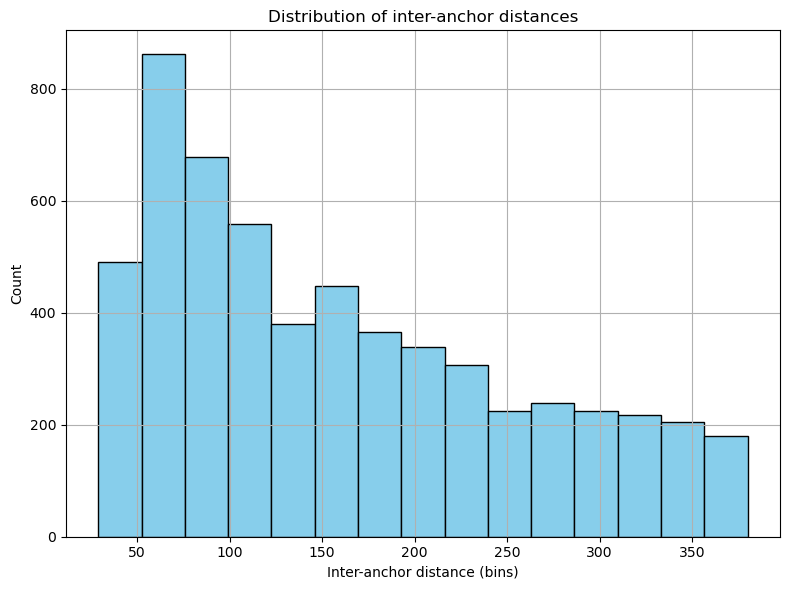

Dots in [30, 50] bin range: 488
Loaded 488 valid patches
  Pile-up shape : (15, 15)
  Max value     : 0.7932
Saved dot mask to:
  /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/natural_features/dots/data_driven_dot_mask.npy


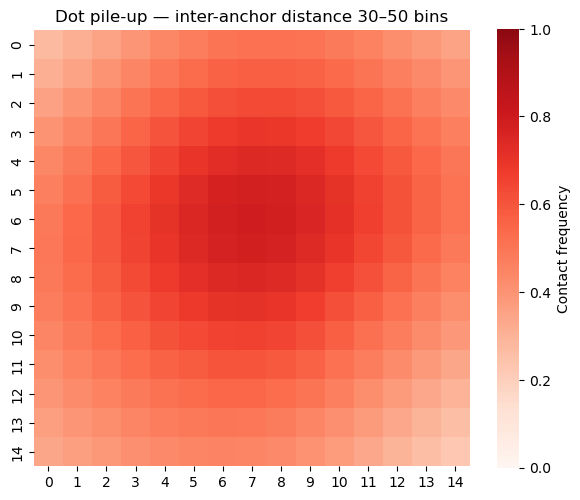

In [5]:
dot_df = pd.read_csv(DOT_TSV, sep="\t")
print(f"Loaded {len(dot_df):,} convergent dots")
print(f"  Minimum inter-anchor distance: {dot_df['anchors_dist'].min()} bins")

plot_anchor_dist_histogram(dot_df)

# -- Filter to target distance range ------------------------------------
mask = (dot_df["anchors_dist"] >= DIST_LOWER_BOUND) & \
        (dot_df["anchors_dist"] <= DIST_UPPER_BOUND)
selected_df = dot_df[mask]
print(f"Dots in [{DIST_LOWER_BOUND}, {DIST_UPPER_BOUND}] bin range: {len(selected_df):,}")

# -- Load patches -------------------------------------------------------
patches = load_patches(selected_df, PATCH_DIR)
if not patches:
    raise ValueError("No valid patches found in the selected distance range.")
print(f"Loaded {len(patches):,} valid patches")

# -- Compute pile-up and save -------------------------------------------
pileup = compute_pileup(patches)
print(f"  Pile-up shape : {pileup.shape}")
print(f"  Max value     : {np.max(pileup):.4f}")

np.save(OUTPUT_MASK, pileup)
print(f"Saved dot mask to:\n  {OUTPUT_MASK}")

# -- Visualise ----------------------------------------------------------
plot_pileup(pileup, DIST_LOWER_BOUND, DIST_UPPER_BOUND, vmin=0.0, vmax=1.0)